# Étape 1 — Préparation des données

Première étape du projet P6 (Home Credit Default Risk). Je charge les 8 tables, je regarde rapidement la cible et les NaN, puis je lance la pipeline de feature engineering. Le code de la pipeline est dans `src/prepare_data.py` (adapté du kernel de jsaguiar).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
DATA_DIR = PROJECT_ROOT / "Data"
OUTPUT_DIR = PROJECT_ROOT / "output"
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\ClementLoire\ObsidianVault_MCP_enabled\05 - Cours\P6 - Initiez-vous au MLOps 1-2


## 1. Inventaire des tables

Toutes joignables sur `SK_ID_CURR`. La cible `TARGET` n'est que dans `application_train.csv`.

In [2]:
tables = [
    "application_train.csv",
    "application_test.csv",
    "bureau.csv",
    "bureau_balance.csv",
    "previous_application.csv",
    "POS_CASH_balance.csv",
    "installments_payments.csv",
    "credit_card_balance.csv",
]

inventory = []
for t in tables:
    p = DATA_DIR / t
    size_mb = p.stat().st_size / 1e6
    n_rows = sum(1 for _ in open(p, encoding="utf-8")) - 1
    inventory.append({"table": t, "size_MB": round(size_mb, 1), "rows": n_rows})
pd.DataFrame(inventory)

,table,size_MB,rows
0,application_train.csv,166.1,307511
1,application_test.csv,26.6,48744
2,bureau.csv,170.0,1716428
3,bureau_balance.csv,375.6,27299925
4,previous_application.csv,405.0,1670214
5,POS_CASH_balance.csv,392.7,10001358
6,installments_payments.csv,723.1,13605401
7,credit_card_balance.csv,424.6,3840312


## 2. Aperçu de `application_train` — la table principale

In [3]:
app = pd.read_csv(DATA_DIR / "application_train.csv")
print("Shape:", app.shape)
print("Colonnes catégorielles:", (app.dtypes == 'object').sum())
print("Colonnes numériques:", (app.dtypes != 'object').sum())
app.head(3)

Shape: (307511, 122)
Colonnes catégorielles: 16
Colonnes numériques: 106


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,...,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,...,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,...,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,...,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### Déséquilibre des classes

Très déséquilibré, à gérer plus tard (pondération ou rééchantillonnage).

                count      %
0 — remboursé  282686  91.93
1 — défaut      24825   8.07


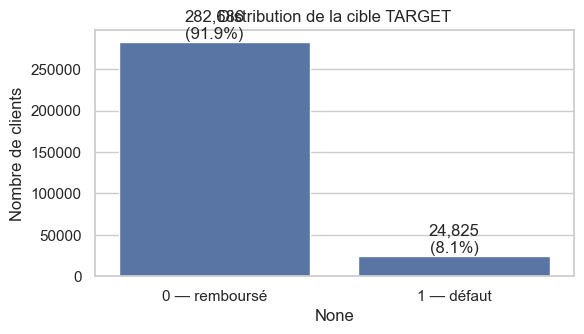

In [4]:
counts = app["TARGET"].value_counts().sort_index()
ratio = counts / counts.sum() * 100
summary = pd.DataFrame({"count": counts, "%": ratio.round(2)})
summary.index = ["0 — remboursé", "1 — défaut"]
print(summary)

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(x=summary.index, y=summary["count"], ax=ax)
for i, (c, r) in enumerate(zip(counts, ratio)):
    ax.text(i, c, f"{c:,}\n({r:.1f}%)", ha="center", va="bottom")
ax.set_title("Distribution de la cible TARGET")
ax.set_ylabel("Nombre de clients")
plt.tight_layout(); plt.show()

### Valeurs manquantes — colonnes les plus impactées

In [5]:
missing = app.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
print(f"{len(missing)} colonnes avec au moins une valeur manquante.")
missing.head(20).to_frame("% manquant")

67 colonnes avec au moins une valeur manquante.


,% manquant
COMMONAREA_AVG,69.872297
COMMONAREA_MODE,69.872297
COMMONAREA_MEDI,69.872297
NONLIVINGAPARTMENTS_MEDI,69.432963
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_AVG,69.432963
FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_AVG,68.354953
LIVINGAPARTMENTS_MEDI,68.354953
LIVINGAPARTMENTS_MODE,68.354953


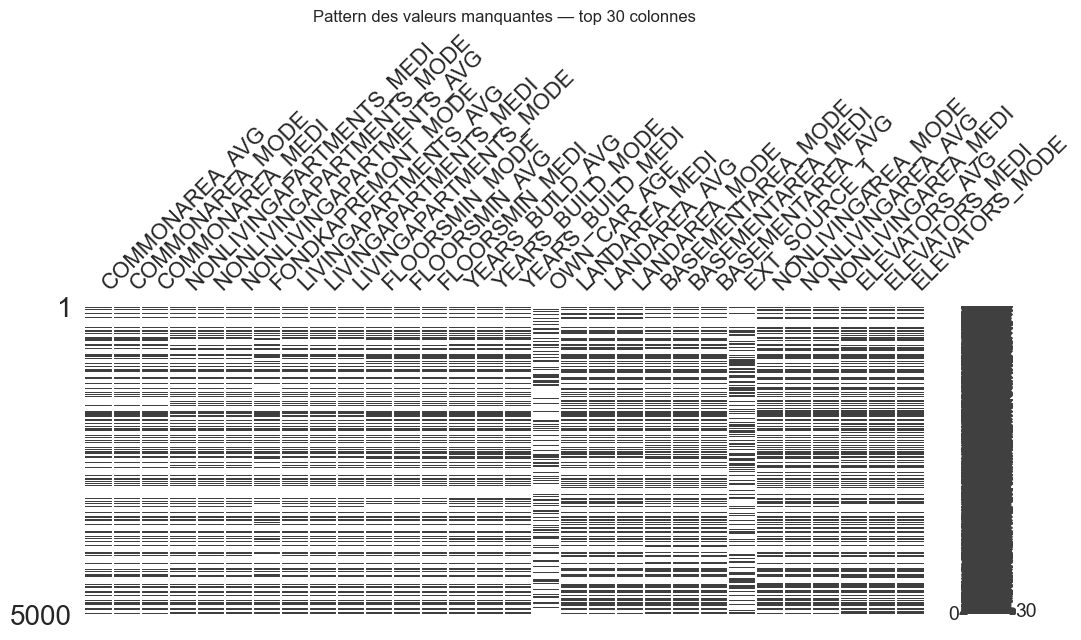

In [6]:
# Visualisation des NaN sur les 30 colonnes les plus problématiques
top_missing_cols = missing.head(30).index.tolist()
msno.matrix(app[top_missing_cols].sample(5000, random_state=42), figsize=(12, 4))
plt.title("Pattern des valeurs manquantes — top 30 colonnes")
plt.show()

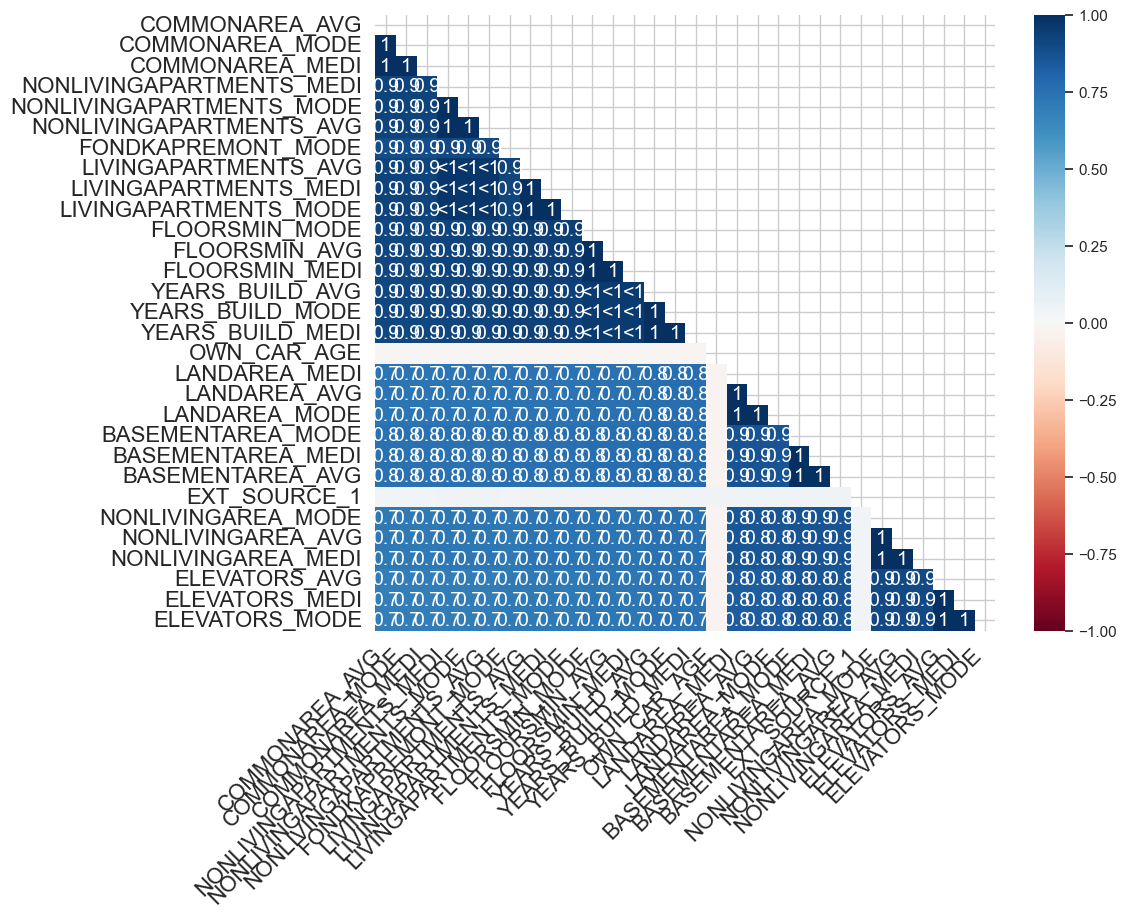

In [7]:
# Heatmap de corrélation des NaN — repère les groupes de colonnes manquantes ensemble
msno.heatmap(app[top_missing_cols], figsize=(10, 8))
plt.show()

Beaucoup de NaN groupés sur les colonnes `*_AVG`, `*_MODE`, `*_MEDI` du logement, ainsi que `EXT_SOURCE_*`. LightGBM gère les NaN nativement, donc on ne touche pas.

## 3. Pipeline complète

On lance `build_dataset()`. Sur le dataset complet, ~3 min et ~6 Go RAM en pic.

In [8]:
import importlib, prepare_data
importlib.reload(prepare_data)

# Mettre num_rows=10000 pour un essai rapide; None = dataset complet.
df = prepare_data.build_dataset(num_rows=None, save=True)
df.shape

Train samples: 307511, test samples: 48744


Application df shape: (356251, 247)
Process application_train + application_test - done in 4s


Bureau df shape: (305811, 116)


Process bureau and bureau_balance - done in 18s


Previous applications df shape: (338857, 249)


...

Process installments payments - done in 18s


Credit card balance df shape: (103558, 141)


Process credit card balance - done in 15s

Final dataset shape: (356251, 797)
TARGET available rows (train): 307507
TARGET missing rows (test): 48744



Saved -> C:\Users\ClementLoire\ObsidianVault_MCP_enabled\05 - Cours\P6 - Initiez-vous au MLOps 1-2\output\feature_dataset.parquet  (278.6 MB)


(356251, 797)

## 4. Contrôles post-pipeline

In [9]:
print(f"Lignes train (TARGET non-NaN) : {df['TARGET'].notna().sum():,}")
print(f"Lignes test  (TARGET NaN)     : {df['TARGET'].isna().sum():,}")
print(f"Nombre total de features      : {df.shape[1] - 2}  (TARGET + SK_ID_CURR exclus)")
print(f"Mémoire                       : {df.memory_usage(deep=True).sum() / 1e9:.2f} Go")

Lignes train (TARGET non-NaN) : 307,507
Lignes test  (TARGET NaN)     : 48,744
Nombre total de features      : 795  (TARGET + SK_ID_CURR exclus)


Mémoire                       : 2.08 Go


In [10]:
# Quelques features créées par la pipeline
created = ["PAYMENT_RATE", "INCOME_CREDIT_PERC", "ANNUITY_INCOME_PERC",
           "DAYS_EMPLOYED_PERC", "INCOME_PER_PERSON"]
df[df["TARGET"].notna()][created + ["TARGET"]].describe().round(3)

,PAYMENT_RATE,INCOME_CREDIT_PERC,ANNUITY_INCOME_PERC,DAYS_EMPLOYED_PERC,INCOME_PER_PERSON,TARGET
count,307495.000,307507.000,307495.000,252133.000,3.075050e+05,307507.000
mean,0.054,0.400,0.181,0.157,9.310608e+04,0.081
std,0.022,0.508,0.095,0.134,1.013739e+05,0.272
min,0.022,0.012,0.000,-0.000,2.812500e+03,0.000
25%,0.037,0.194,0.115,0.056,4.725000e+04,0.000
50%,0.050,0.306,0.163,0.119,7.500000e+04,0.000
75%,0.064,0.495,0.229,0.219,1.125000e+05,0.000
max,0.124,208.003,1.876,0.729,3.900000e+07,1.000


In [11]:
# Vérifie que le parquet est bien sur disque
out_path = OUTPUT_DIR / "feature_dataset.parquet"
print(f"{out_path}  →  {out_path.stat().st_size / 1e6:.1f} Mo")

C:\Users\ClementLoire\ObsidianVault_MCP_enabled\05 - Cours\P6 - Initiez-vous au MLOps 1-2\output\feature_dataset.parquet  →  278.6 Mo


## 5. Qualité des features

Quelques contrôles que je voulais poser avant de modéliser : doublons, types, distributions, et la logique des variables que la pipeline construit.

In [12]:
# Doublons : un client (SK_ID_CURR) ne doit apparaître qu'une fois
print('SK_ID_CURR dupliqués (train brut)   :', app['SK_ID_CURR'].duplicated().sum())
print('Lignes entièrement dupliquées (brut):', app.duplicated().sum())
print('SK_ID_CURR dupliqués (dataset final):', df['SK_ID_CURR'].duplicated().sum())
print('\nTypes du dataset final :')
print(df.dtypes.value_counts())

SK_ID_CURR dupliqués (train brut)   : 0


Lignes entièrement dupliquées (brut): 0
SK_ID_CURR dupliqués (dataset final): 0

Types du dataset final :
float64    606
bool       133
int64       42
object      16
Name: count, dtype: int64


Aucun doublon de `SK_ID_CURR` : chaque table satellite est agrégée par client (`groupby('SK_ID_CURR').agg(...)`) avant la jointure `left`, donc une jointure n'ajoute jamais de ligne — elle élargit seulement les colonnes. C'est ce qui garantit une ligne par crédit.

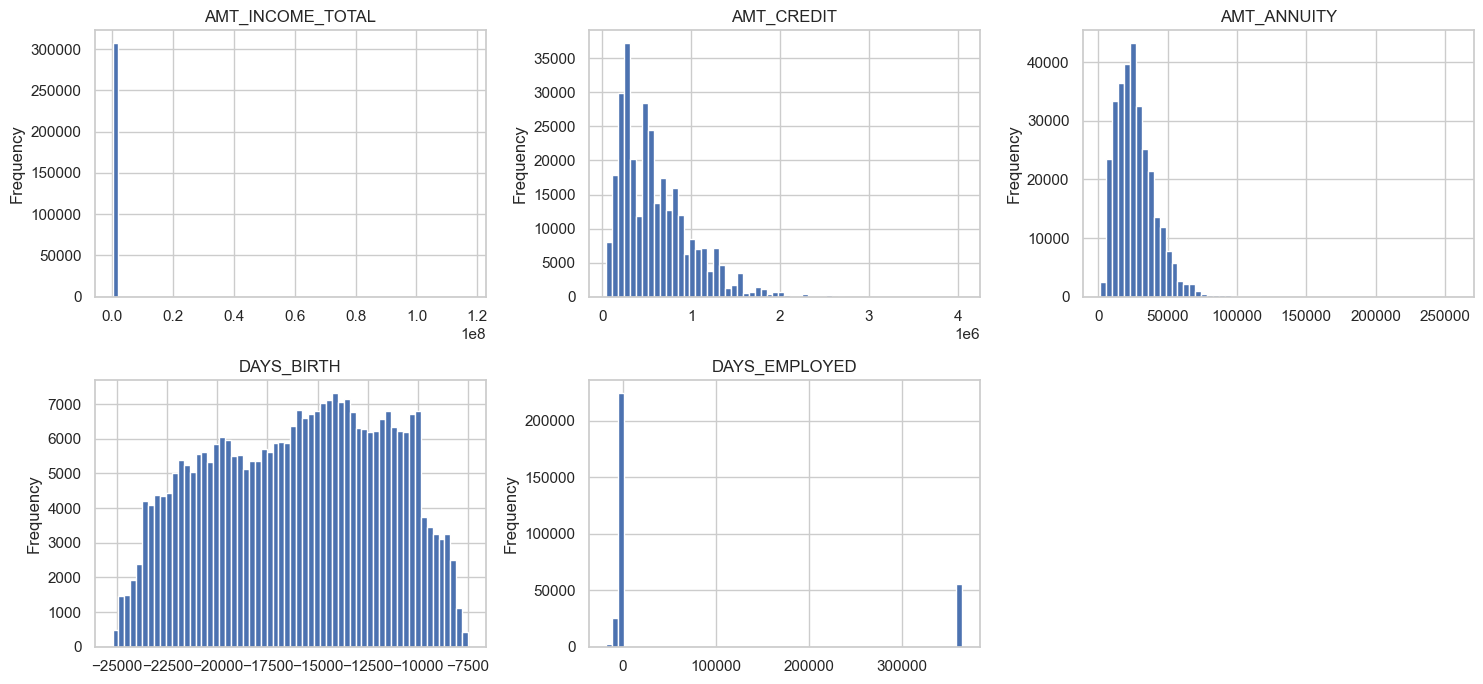

DAYS_EMPLOYED == 365243 (sentinelle) : 55374 lignes
AMT_INCOME_TOTAL max : 117000000.0


In [13]:
# Distributions de quelques variables clés + anomalies connues
key_num = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.ravel(), key_num):
    app[c].plot.hist(bins=60, ax=ax); ax.set_title(c)
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.show()
print('DAYS_EMPLOYED == 365243 (sentinelle) :', int((app['DAYS_EMPLOYED'] == 365243).sum()), 'lignes')
print('AMT_INCOME_TOTAL max :', app['AMT_INCOME_TOTAL'].max())

La sentinelle `DAYS_EMPLOYED == 365243` (~1000 ans) marque en réalité des chômeurs / retraités ; `prepare_data.py` la remplace par `NaN`. `AMT_INCOME_TOTAL` a une queue extrême (un revenu à 117 M) — LightGBM y est robuste, donc je ne winsorise pas. Les ratios comme `INCOME_CREDIT_PERC` peuvent atteindre des valeurs extrêmes ou `±inf` ; ils sont nettoyés au chargement (`training.load_training_data`).

In [14]:
# Encodage et imputation
cat_cols = app.select_dtypes('object').columns
print(f'{len(cat_cols)} colonnes catégorielles encodées en one-hot par la pipeline.')
na_share = df.isna().mean()
print(f'Colonnes avec des NaN dans le dataset final : {int((na_share > 0).sum())} / {df.shape[1]}')
print('LightGBM gère les NaN nativement -> pas d\'imputation pour le boosting ;')
print('imputation médiane seulement pour LR / RF / MLP, sensibles aux NaN.')

16 colonnes catégorielles encodées en one-hot par la pipeline.


Colonnes avec des NaN dans le dataset final : 617 / 797
LightGBM gère les NaN nativement -> pas d'imputation pour le boosting ;
imputation médiane seulement pour LR / RF / MLP, sensibles aux NaN.


### Variables dérivées et logique métier

Les ratios construits dans `prepare_data.py` traduisent des notions de risque crédit :

- `PAYMENT_RATE = AMT_ANNUITY / AMT_CREDIT` — poids de l'annuité dans le crédit (effort de remboursement).
- `ANNUITY_INCOME_PERC = AMT_ANNUITY / AMT_INCOME_TOTAL` — taux d'endettement.
- `INCOME_CREDIT_PERC = AMT_INCOME_TOTAL / AMT_CREDIT` — capacité du revenu à couvrir le crédit.
- `DAYS_EMPLOYED_PERC = DAYS_EMPLOYED / DAYS_BIRTH` — ancienneté d'emploi rapportée à l'âge.
- `INCOME_PER_PERSON = AMT_INCOME_TOTAL / CNT_FAM_MEMBERS` — revenu par personne du foyer.

Côté tables satellites, les agrégats `PREV_*`, `BURO_*`, `INSTAL_*` (moyennes, sommes, variances) résument l'historique de crédit externe et interne du client.